# Reward-Value Decoding — Whole-Brain + ROI Group Results

RidgeCV, leave-one-run-out CV, continuous target = objective reward level of the first
stimulus (`first_stim_value`, integers 1–5; source: BBT). Four masks: whole-brain,
visual cortex (Harvard-Oxford), vmPFC and striatum (Bartra et al. 2013 meta-analytic ROIs).

Metric: Pearson `r` between cross-validated predictions and true reward level (null = 0),
plus `r²` for reference. This is the "plain decoding" baseline — no spatial map — from
`run_qvalue_decoding.py`, alongside the eventual `searchlight_results.ipynb`/
`frem_results.ipynb` reward-value counterparts.

**Status (2026-08-07):** `run_qvalue_decoding.py` just landed on the `qvalue-decoding`
branch; only sub-01 has been run so far (smoke test on the cluster). This notebook is
built to run against whatever subjects have output at any given time — rerun after
`submit_qvalue_decoding.sh` finishes the full 59-subject cohort.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

DATA_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives/decoding")
TAG = "reward"   # filename tag for target_col='first_stim_value' (see run_qvalue_decoding.py)
MASKS = ["wholebrain", "visualcortex", "vmpfc", "striatum"]
MASK_LABELS = {"wholebrain": "Whole brain", "visualcortex": "Visual cortex",
               "vmpfc": "vmPFC", "striatum": "Striatum"}
COLORS = {"wholebrain": "#4C72B0", "visualcortex": "#DD8452",
          "vmpfc": "#55A868", "striatum": "#C44E52"}
NULL_R = 0.0

In [2]:
records = []
pred_frames = []

for sub_dir in sorted(DATA_DIR.glob("sub-*")):
    sub_id = sub_dir.name.replace("sub-", "")
    summary_file = sub_dir / f"sub-{sub_id}_qvalue_decoding_{TAG}.csv"
    pred_file = sub_dir / f"sub-{sub_id}_qvalue_decoding_predictions_{TAG}.csv"
    if not summary_file.exists():
        continue

    summary = pd.read_csv(summary_file)
    summary.insert(0, "subject", sub_id)
    records.append(summary)

    if pred_file.exists():
        preds = pd.read_csv(pred_file)
        preds.insert(0, "subject", sub_id)
        pred_frames.append(preds)

df = (pd.concat(records, ignore_index=True) if records
      else pd.DataFrame(columns=["subject", "mask", "n_voxels", "r", "r2", "n_trials"]))
preds_df = (pd.concat(pred_frames, ignore_index=True) if pred_frames
            else pd.DataFrame(columns=["subject", "mask", "run", "y_true", "y_pred"]))

n_subjects = df["subject"].nunique()
print(f"{n_subjects} subject(s) loaded, masks: {sorted(df['mask'].unique()) if n_subjects else []}")

1 subject(s) loaded, masks: ['striatum', 'visualcortex', 'vmpfc', 'wholebrain']


## Group r / r²

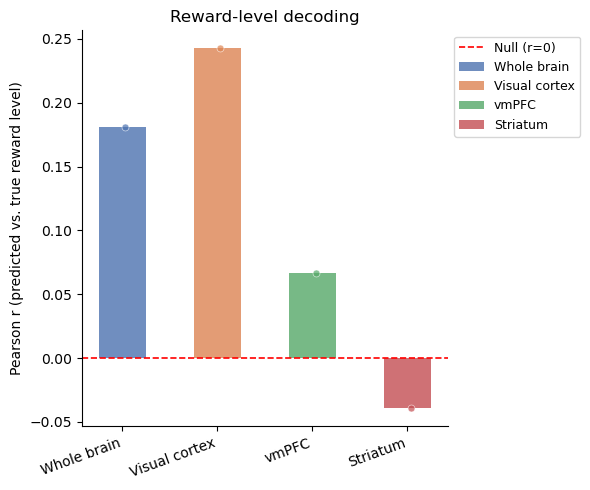

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(MASKS))
w = 0.5

for i, mask in enumerate(MASKS):
    vals = df.loc[df["mask"] == mask, "r"].values
    if len(vals) == 0:
        continue
    color = COLORS[mask]
    ax.bar(i, vals.mean(), width=w, color=color, alpha=0.8, label=MASK_LABELS[mask], zorder=2)
    if len(vals) > 1:
        ax.errorbar(i, vals.mean(), yerr=vals.std() / np.sqrt(len(vals)),
                    fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)
    jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(vals))
    ax.scatter(i + jitter, vals, color=color, edgecolors='white',
               linewidth=0.5, s=25, alpha=0.7, zorder=4)

ax.axhline(NULL_R, color='red', linestyle='--', linewidth=1.2, label='Null (r=0)')
ax.set_xticks(x)
ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=20, ha='right')
ax.set_ylabel("Pearson r (predicted vs. true reward level)")
ax.set_title("Reward-level decoding")
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)

for i, mask in enumerate(MASKS):
    vals = df.loc[df["mask"] == mask, "r"].values
    if len(vals) < 2:
        continue
    t, p = stats.ttest_1samp(vals, NULL_R)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(i, vals.mean() + vals.std()/np.sqrt(len(vals)) + 0.01, sig, ha='center', fontsize=11)
    print(f"{mask}: mean r={vals.mean():.3f}, t({len(vals)-1})={t:.2f}, p={p:.2e}  {sig}")

plt.tight_layout()
plt.show()

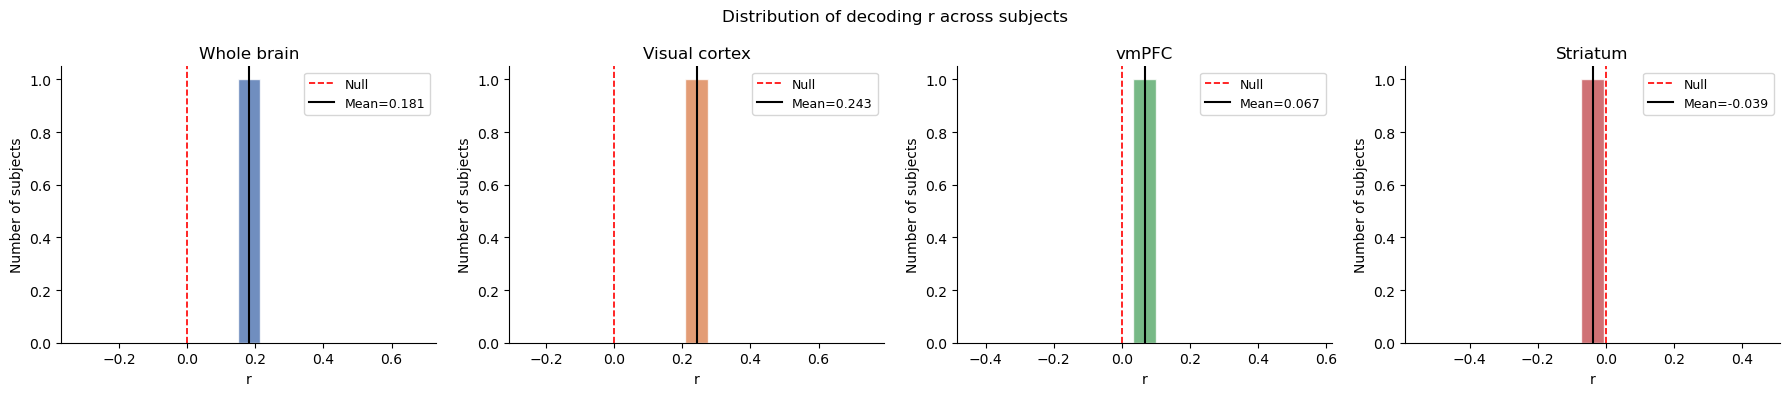

In [4]:
fig, axes = plt.subplots(1, len(MASKS), figsize=(4.5 * len(MASKS), 4), sharey=False)

for ax, mask in zip(axes, MASKS):
    vals = df.loc[df["mask"] == mask, "r"].values
    color = COLORS[mask]
    ax.hist(vals, bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(NULL_R, color='red', linestyle='--', linewidth=1.2, label='Null')
    if len(vals):
        ax.axvline(vals.mean(), color='black', linestyle='-', linewidth=1.5, label=f'Mean={vals.mean():.3f}')
    ax.set_xlabel("r")
    ax.set_ylabel("Number of subjects")
    ax.set_title(MASK_LABELS[mask])
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Distribution of decoding r across subjects")
plt.tight_layout()
plt.show()

## Predicted vs. true reward level

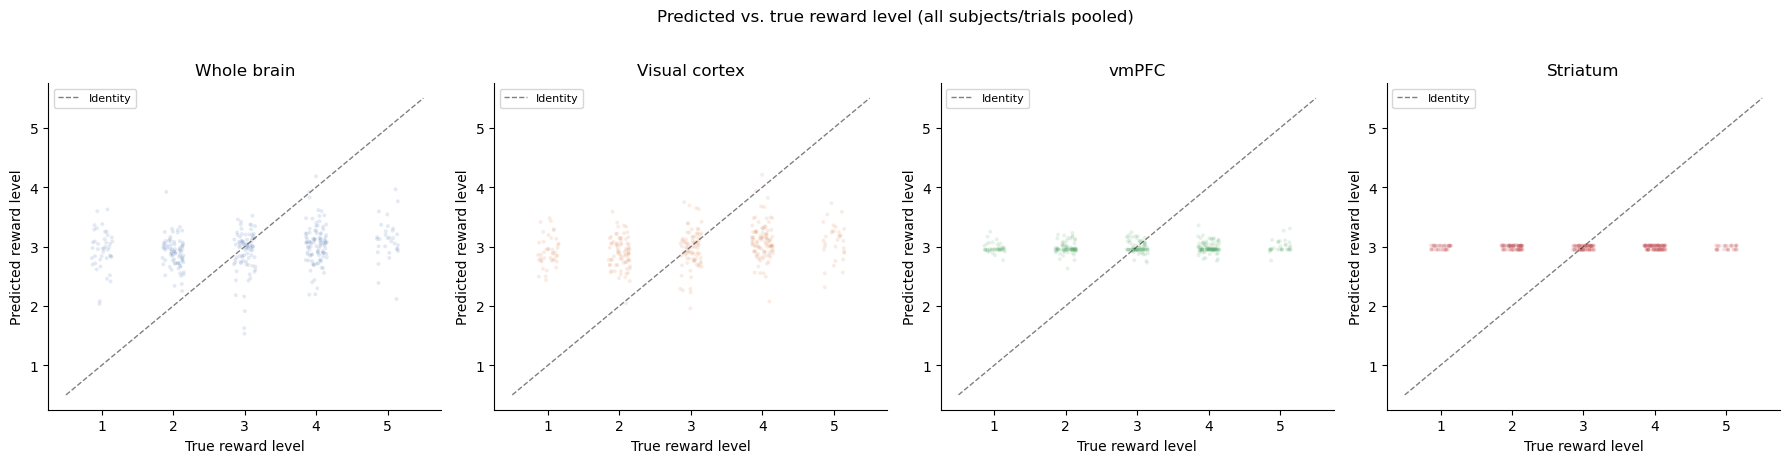

In [5]:
fig, axes = plt.subplots(1, len(MASKS), figsize=(4.5 * len(MASKS), 4.5))

for ax, mask in zip(axes, MASKS):
    sub = preds_df[preds_df["mask"] == mask]
    color = COLORS[mask]
    rng = np.random.default_rng(0)
    jitter_x = sub["y_true"] + rng.uniform(-0.15, 0.15, len(sub))
    ax.scatter(jitter_x, sub["y_pred"], color=color, alpha=0.15, s=8, edgecolors='none')
    if len(sub):
        lims = [sub["y_true"].min() - 0.5, sub["y_true"].max() + 0.5]
        ax.plot(lims, lims, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Identity')
    ax.set_xlabel("True reward level")
    ax.set_ylabel("Predicted reward level")
    ax.set_title(MASK_LABELS[mask])
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Predicted vs. true reward level (all subjects/trials pooled)", y=1.02)
plt.tight_layout()
plt.show()

## Individual subject r

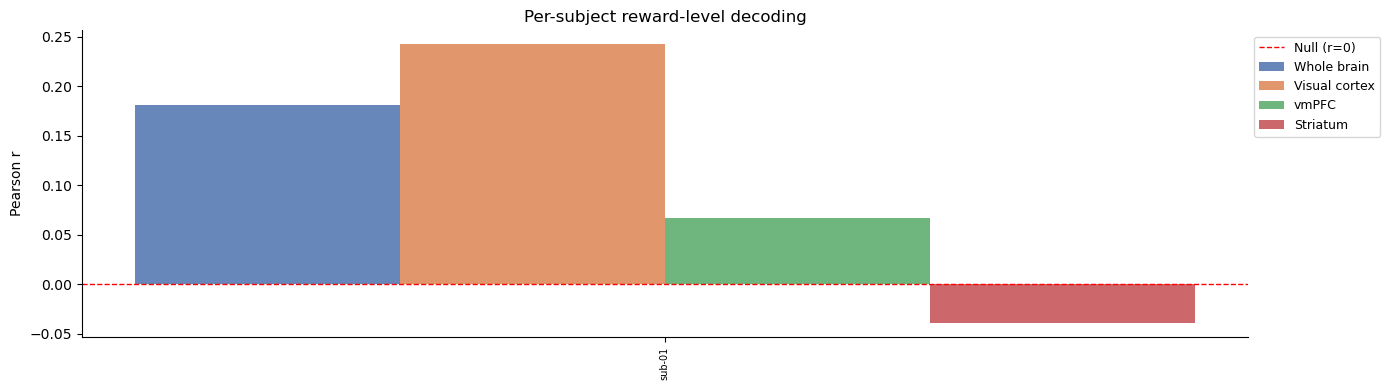

In [6]:
subjects = sorted(df["subject"].unique())
pivot = df.pivot(index="subject", columns="mask", values="r").reindex(subjects)

fig, ax = plt.subplots(figsize=(max(14, 0.25 * len(subjects)), 4))
x = np.arange(len(subjects))
n_masks = len(MASKS)
width = 0.8 / n_masks

for i, mask in enumerate(MASKS):
    if mask not in pivot.columns:
        continue
    offset = (i - (n_masks - 1) / 2) * width
    ax.bar(x + offset, pivot[mask], width=width, label=MASK_LABELS[mask], color=COLORS[mask], alpha=0.85)

ax.axhline(NULL_R, color='red', linestyle='--', linewidth=1, label='Null (r=0)')
ax.set_xticks(x)
ax.set_xticklabels([f"sub-{s}" for s in subjects], rotation=90, fontsize=7)
ax.set_ylabel("Pearson r")
ax.set_title("Per-subject reward-level decoding")
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Findings summary

_(Fill in once the full 59-subject cohort has run — currently n=1, sub-01 only.)_

- **Decodability:** which masks show `r` significantly above 0 across the group, and the
  ordering across whole-brain / visual-cortex / vmPFC / striatum.
- **vmPFC/striatum vs. visual cortex:** value-coding regions (vmPFC, striatum) are the
  analyses of actual interest here — visual cortex and whole-brain serve mostly as a
  sanity-check floor/ceiling, given the strong visual-cortex signal already established
  for category decoding.
- **Bottom line:** this is the cheapest reward-decodability check, run before the
  searchlight/FREM spatial maps — a null result here doesn't rule out spatially localized
  signal (searchlight can find pockets a whole-ROI average would wash out), but a clear
  positive result motivates spending compute on the spatial analyses.